<a href="https://colab.research.google.com/github/madhavi-analytics/IMDB-Sentiment-Chatbot/blob/main/IMDB_Sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

**load the Data**

In [ ]:
df=pd.read_excel('/content/IMDB Dataset.xlsx')
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
13554,I'm a huge lover of really bad B movies. And I...,negative
13555,Now I myself had previously seen a few episode...,positive
13556,This film started off really tense when a poor...,negative
13557,"First off, this movie was a wild ride the whol...",positive


**display the first & last 5 rows**

In [ ]:
df.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.tail(5)

,review,sentiment
13554,I'm a huge lover of really bad B movies. And I...,negative
13555,Now I myself had previously seen a few episode...,positive
13556,This film started off really tense when a poor...,negative
13557,"First off, this movie was a wild ride the whol...",positive
13558,"well-made documentary about a sailing race, sa...",positive


**Total no.of Reviews**

In [ ]:
df['review'].count()

np.int64(13559)

**Count of each statement**

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
negative,6840
positive,6719


**Check balance**

In [ ]:
df['sentiment'].value_counts(normalize=True)

,proportion
sentiment,
negative,0.504462
positive,0.495538


**missing values**

In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


 **NOTE:**

**UNDERSTANDING**
* Balanced dataset - good model performance
* No missing values - no need for imputation


# **Text Preprocessing**

Raw text → clean text → tokens → meaningful words

In [ ]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

**Full forms**
   * re    -  Regular Expression
   * nltk - Natural Language Toolkit
   * corpus - Text Collection
   * wordnet - wordnet Database
   *punkt - tokenizer model

In [ ]:
def clean_text(text):
  return text

**convert text into lower case**

In [ ]:
df['review_lower']=df['review'].str.lower()
print(df[['review','review_lower']].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        review_lower  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production. <br /><br />the...  
2  i thought this was a wonderful way to spend ti...  
3  basically there's a family where a little boy ...  
4  petter mattei's "love in the time of money" is...  


**NOTE:**
convert all characters in text into lower case(a-z)

**Remove HTML tags**

In [ ]:
def remove_html(text):
  return re.sub(r'<.*?>','',text)
df['review_clean']=df['review_lower'].apply(remove_html)
print(df[['review_lower','review_clean']].head())

                                        review_lower  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production. <br /><br />the...   
2  i thought this was a wonderful way to spend ti...   
3  basically there's a family where a little boy ...   
4  petter mattei's "love in the time of money" is...   

                                        review_clean  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production. the filming tec...  
2  i thought this was a wonderful way to spend ti...  
3  basically there's a family where a little boy ...  
4  petter mattei's "love in the time of money" is...  


**NOTE:**

 * Removes unnecessary HTML noise

* Makes text clean for NLP models

* Improves accuracy

**Remove numbers**

In [ ]:
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

df['no_numbers'] = df['review_clean'].apply(remove_numbers)
print(df[['review_clean','no_numbers']].head())

                                        review_clean  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production. the filming tec...   
2  i thought this was a wonderful way to spend ti...   
3  basically there's a family where a little boy ...   
4  petter mattei's "love in the time of money" is...   

                                          no_numbers  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production. the filming tec...  
2  i thought this was a wonderful way to spend ti...  
3  basically there's a family where a little boy ...  
4  petter mattei's "love in the time of money" is...  


**NOTE:**
* removes all numeric values(0-9) from text
* Helps reduce noise in text data
* Numbers usually do not contribute to sentiment analysis

**Remove special characters**


In [ ]:
def remove_special(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)

df['review_clean2'] = df['review_clean'].apply(remove_special)

print(df[['review_clean', 'review_clean2']].head())

                                        review_clean  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production. the filming tec...   
2  i thought this was a wonderful way to spend ti...   
3  basically there's a family where a little boy ...   
4  petter mattei's "love in the time of money" is...   

                                       review_clean2  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production the filming tech...  
2  i thought this was a wonderful way to spend ti...  
3  basically theres a family where a little boy j...  
4  petter matteis love in the time of money is a ...  


**Rmove extra whitespaces**

In [ ]:
def remove_whitespace(text):
    return re.sub(r'\s+', ' ', text).strip()

df['review_clean3'] = df['review_clean2'].apply(remove_whitespace)

print(df[['review_clean2', 'review_clean3']].head())

                                       review_clean2  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production the filming tech...   
2  i thought this was a wonderful way to spend ti...   
3  basically theres a family where a little boy j...   
4  petter matteis love in the time of money is a ...   

                                       review_clean3  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production the filming tech...  
2  i thought this was a wonderful way to spend ti...  
3  basically theres a family where a little boy j...  
4  petter matteis love in the time of money is a ...  


**Tokenize the cleaned text into individual words**

In [ ]:
from nltk.tokenize import word_tokenize

def tokenize_text(text):
    return word_tokenize(text)

df['tokens'] = df['review_clean3'].apply(tokenize_text)

print(df[['review_clean3', 'tokens']].head())

                                       review_clean3  \
0  one of the other reviewers has mentioned that ...   
1  a wonderful little production the filming tech...   
2  i thought this was a wonderful way to spend ti...   
3  basically theres a family where a little boy j...   
4  petter matteis love in the time of money is a ...   

                                              tokens  
0  [one, of, the, other, reviewers, has, mentione...  
1  [a, wonderful, little, production, the, filmin...  
2  [i, thought, this, was, a, wonderful, way, to,...  
3  [basically, theres, a, family, where, a, littl...  
4  [petter, matteis, love, in, the, time, of, mon...  


**Remove english stopwords using nltk**

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['tokens_clean'] = df['tokens'].apply(remove_stopwords)

print(df[['tokens', 'tokens_clean']].head())

                                              tokens  \
0  [one, of, the, other, reviewers, has, mentione...   
1  [a, wonderful, little, production, the, filmin...   
2  [i, thought, this, was, a, wonderful, way, to,...   
3  [basically, theres, a, family, where, a, littl...   
4  [petter, matteis, love, in, the, time, of, mon...   

                                        tokens_clean  
0  [one, reviewers, mentioned, watching, oz, epis...  
1  [wonderful, little, production, filming, techn...  
2  [thought, wonderful, way, spend, time, hot, su...  
3  [basically, theres, family, little, boy, jake,...  
4  [petter, matteis, love, time, money, visually,...  


**Perform Lemmatization on the tokens**

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['tokens_lemma'] = df['tokens_clean'].apply(lemmatize_tokens)

print(df[['tokens_clean', 'tokens_lemma']].head())

                                        tokens_clean  \
0  [one, reviewers, mentioned, watching, oz, epis...   
1  [wonderful, little, production, filming, techn...   
2  [thought, wonderful, way, spend, time, hot, su...   
3  [basically, theres, family, little, boy, jake,...   
4  [petter, matteis, love, time, money, visually,...   

                                        tokens_lemma  
0  [one, reviewer, mentioned, watching, oz, episo...  
1  [wonderful, little, production, filming, techn...  
2  [thought, wonderful, way, spend, time, hot, su...  
3  [basically, there, family, little, boy, jake, ...  
4  [petter, matteis, love, time, money, visually,...  


**Join the tokens**

In [ ]:
def join_words(tokens):
    return " ".join(tokens)

df['final_clean_text'] = df['tokens_lemma'].apply(join_words)

print(df[['tokens_lemma', 'final_clean_text']].head())

                                        tokens_lemma  \
0  [one, reviewer, mentioned, watching, oz, episo...   
1  [wonderful, little, production, filming, techn...   
2  [thought, wonderful, way, spend, time, hot, su...   
3  [basically, there, family, little, boy, jake, ...   
4  [petter, matteis, love, time, money, visually,...   

                                    final_clean_text  
0  one reviewer mentioned watching oz episode you...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically there family little boy jake think t...  
4  petter matteis love time money visually stunni...  


**Apply the funtion to entire review column**

In [ ]:
df['clean_review'] = df['review'].apply(clean_text)
print(df[['review','clean_review']].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        clean_review  
0  One of the other reviewers has mentioned that ...  
1  A wonderful little production. <br /><br />The...  
2  I thought this was a wonderful way to spend ti...  
3  Basically there's a family where a little boy ...  
4  Petter Mattei's "Love in the Time of Money" is...  


**One review before and after**

In [ ]:
print("Before:\n", df['review'][0])
print("\nAfter:\n", df['clean_review'][0])

Before:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due t

# **Feature Engneering - Vectorization**

**Convert target variable (sentiment into numerical)**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['sentiment'])

print(df[['sentiment', 'sentiment_encoded']].head())

  sentiment  sentiment_encoded
0  positive                  1
1  positive                  1
2  positive                  1
3  negative                  0
4  positive                  1


**Explanation:**
   * positoive - 1

  * Negative - 0
  
  * label encoding is used to Convert categorical data into numerical form
*  Assigns a unique number to each category

**Apply Bag of Words (CountVectorizer)**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=5000)
X_bow = cv.fit_transform(df['clean_review'])
print(X_bow)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1593979 stored elements and shape (13559, 5000)>
  Coords	Values
  (0, 3113)	1
  (0, 3089)	7
  (0, 4440)	16
  (0, 3142)	2
  (0, 3690)	1
  (0, 2064)	1
  (0, 2818)	1
  (0, 4438)	4
  (0, 154)	1
  (0, 4827)	2
  (0, 2446)	2
  (0, 3168)	6
  (0, 1530)	2
  (0, 4990)	3
  (0, 2641)	3
  (0, 424)	2
  (0, 2173)	1
  (0, 4455)	1
  (0, 296)	2
  (0, 3706)	2
  (0, 321)	4
  (0, 4466)	3
  (0, 2372)	9
  (0, 1575)	1
  (0, 4867)	2
  :	:
  (13558, 1335)	1
  (13558, 3829)	1
  (13558, 1031)	1
  (13558, 1579)	1
  (13558, 4105)	1
  (13558, 557)	1
  (13558, 4210)	1
  (13558, 4363)	1
  (13558, 2415)	1
  (13558, 4597)	2
  (13558, 1680)	1
  (13558, 1533)	1
  (13558, 4411)	1
  (13558, 203)	1
  (13558, 3032)	1
  (13558, 94)	1
  (13558, 1181)	1
  (13558, 2671)	1
  (13558, 3511)	1
  (13558, 3631)	1
  (13558, 1334)	1
  (13558, 4006)	1
  (13558, 1842)	1
  (13558, 2733)	1
  (13558, 3553)	1


**Shape of the Bag of Words**

In [ ]:
print(X_bow.shape)

(13559, 5000)


**Explanation:**
* CountVectorizer-based on Bag of Words (BoW) technique
* Counts how many times each word appears in a document
*  Creates a vocabulary of unique words
*  Output is a matrix of word frequencies


# **TF-IDF Vectorizer**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_review'])
print(X_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1593979 stored elements and shape (13559, 5000)>
  Coords	Values
  (0, 3113)	0.01946403259703346
  (0, 3089)	0.09169242772605726
  (0, 4440)	0.20127747427681278
  (0, 3142)	0.05732546821967374
  (0, 3690)	0.07026938816263127
  (0, 2064)	0.02395497425560901
  (0, 2818)	0.05953681674040906
  (0, 4438)	0.06042135830535309
  (0, 154)	0.03102515223496636
  (0, 4827)	0.07160194031014881
  (0, 2446)	0.04619930357437268
  (0, 3168)	0.4864968801202485
  (0, 1530)	0.10657015276077324
  (0, 4990)	0.059972650436472145
  (0, 2641)	0.12331120539884961
  (0, 424)	0.03903145287714774
  (0, 2173)	0.07672965806433694
  (0, 4455)	0.02290902952343694
  (0, 296)	0.040035639972534
  (0, 3706)	0.07927439548509815
  (0, 321)	0.07153584945551912
  (0, 4466)	0.04083995121477461
  (0, 2372)	0.12422005963885252
  (0, 1575)	0.05383230183862561
  (0, 4867)	0.0479423326960779
  :	:
  (13558, 1335)	0.07486872182466789
  (13558, 3829)	0.10912132009325558
  

**Explanation:**
* Stands for Term Frequency – Inverse Document Frequency
* Measures importance of a word in a document
*  Gives high weight to important words
*  Gives low weight to common words (like the, is)
*  Improves model performance compared to Bag of Words

**shape of the TF-IDF feature matrix**

In [ ]:
print(X_tfidf.shape)

(13559, 5000)


# **Train-Test Split**

**split the dataset (75:25ratio)**

In [ ]:
from sklearn.model_selection import train_test_split

# Features (use TF-IDF)
X = X_tfidf

# Target
y = df['sentiment_encoded']

# Split (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1192018 stored elements and shape (10169, 5000)>
  Coords	Values
  (0, 3113)	0.08179400755406717
  (0, 3089)	0.12844017272520314
  (0, 4440)	0.12335042231711088
  (0, 4438)	0.10579567322909837
  (0, 2446)	0.032357342247522555
  (0, 4990)	0.028002667075417587
  (0, 424)	0.0273370804633621
  (0, 296)	0.0280403989771066
  (0, 321)	0.025051351261964477
  (0, 4466)	0.11441490902140986
  (0, 2372)	0.15467019044355912
  (0, 4867)	0.06715627064352983
  (0, 2786)	0.07787269454533541
  (0, 74)	0.09812558478098057
  (0, 4816)	0.050466629837960866
  (0, 235)	0.10853428119551128
  (0, 2271)	0.059175558197396866
  (0, 3045)	0.02648736409465386
  (0, 3129)	0.09843186629629806
  (0, 3025)	0.03685714763481644
  (0, 4515)	0.09243671120341715
  (0, 2379)	0.09721532177031424
  (0, 3111)	0.10165253381950866
  (0, 196)	0.0289340238973928
  (0, 4054)	0.06121937249383981
  :	:
  (10168, 1867)	0.051785111391627406
  (10168, 4341)	0.0561081556193893


**Explanatoion**

* Splits dataset into training and testing data
*  75% → Training data (used to train model)
* 25% → Testing data (used to evaluate model)
* Helps check how model performs on unseen data
*  Prevents overfitting
*  Ensures model generalization


**Display shapes**

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (10169, 5000)
X_test shape: (3390, 5000)
y_train shape: (10169,)
y_test shape: (3390,)


**Note:**
* Used to check size of training and testing data
*  Ensures data is split correctly (75:25)
*  Helps verify number of samples and features
*  Important before model training



# **Model Building - Classical NLP Models**

**train a Naive Bayes classifier**

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# Train model using BoW
nb_model = MultinomialNB()
nb_model.fit(X_bow, df['sentiment_encoded'])

MultinomialNB()

**Explanation:**

* Assumes features are independent (naive assumption)
*  Works very well for text classification (NLP)
*  Fast and efficient for large datasets
*  Commonly used for sentiment analysis, spam detection

**Predict the sentiment for test data**

In [ ]:
y_pred = nb_model.predict(X_test)
print(y_pred)

[1 0 0 ... 1 0 1]


**Note:**
* Uses learned patterns from training data
*  Output will be predicted sentiment (0 or 1)


**the model using Accuracy Score**

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8581120943952802


**Note:**

*  Measures how many predictions are correct
*  Compares actual values (y_test) with predicted values (y_pred)
*  Value ranges from 0 to 1
1 → Perfect model
0 → Completely wrong
*  Expressed as percentage (%)

**Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[1465  250]
 [ 231 1444]]


**Note:**
* Compares actual values vs predicted values
* Shows how many predictions are correct and incorrect*



**Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1715
           1       0.85      0.86      0.86      1675

    accuracy                           0.86      3390
   macro avg       0.86      0.86      0.86      3390
weighted avg       0.86      0.86      0.86      3390



**Note:**

 gives performance for each class(postive & negative)
* Precision - Out of predicted positives, how many are correct
* Recall - out of actul positives, how many are correctly predicted
* F1 score - balance between precision and recall
* Support - Number of actual samples in each class

**Repeat steps 23-25using TF-IDF Features**

In [ ]:
from sklearn.metrics import classification_report

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Model:", model.__class__.__name__)
    print(classification_report(y_test, y_pred))
    print("-"*50)

# **Additional model (functionalization Approach)**


**Reusable function**

In [ ]:
from sklearn.metrics import classification_report

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Model:", model.__class__.__name__)
    print(classification_report(y_test, y_pred))
    print("-"*50)

**Decision Tree Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

evaluate_model(DecisionTreeClassifier(), X_train, X_test, y_train, y_test)

Model: DecisionTreeClassifier
              precision    recall  f1-score   support

           0       0.71      0.72      0.71      1715
           1       0.71      0.69      0.70      1675

    accuracy                           0.71      3390
   macro avg       0.71      0.71      0.71      3390
weighted avg       0.71      0.71      0.71      3390

--------------------------------------------------


**K-Nearest Neighbors classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

evaluate_model(KNeighborsClassifier(), X_train, X_test, y_train, y_test)

Model: KNeighborsClassifier
              precision    recall  f1-score   support

           0       0.67      0.74      0.71      1715
           1       0.71      0.63      0.67      1675

    accuracy                           0.69      3390
   macro avg       0.69      0.69      0.69      3390
weighted avg       0.69      0.69      0.69      3390

--------------------------------------------------


**Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

evaluate_model(RandomForestClassifier(), X_train, X_test, y_train, y_test)

Model: RandomForestClassifier
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1715
           1       0.85      0.83      0.84      1675

    accuracy                           0.85      3390
   macro avg       0.85      0.85      0.85      3390
weighted avg       0.85      0.85      0.85      3390

--------------------------------------------------


# **Word Embeddings & visualization**

**Generate a word cloud for positive**

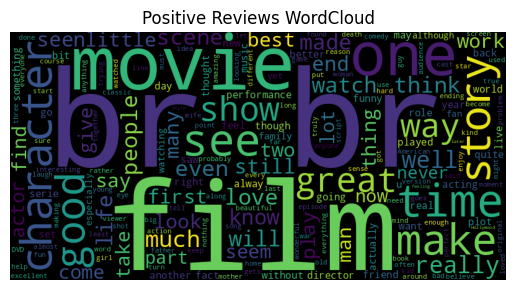

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(df[df['sentiment_encoded'] == 1]['clean_review'])

wc_positive = WordCloud(width=800, height=400).generate(positive_text)

plt.imshow(wc_positive)
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

**Generate a word cloud for negative**

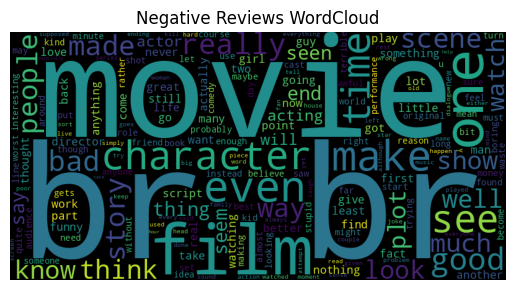

In [ ]:
negative_text = " ".join(df[df['sentiment_encoded'] == 0]['clean_review'])

wc_negative = WordCloud(width=800, height=400).generate(negative_text)

plt.imshow(wc_negative)
plt.axis("off")
plt.title("Negative Reviews WordCloud")
plt.show()

Word cloud visulizes the most frequent words in postive and negative reviews helping identify common pattern

**Identify most frequency words**

In [ ]:
from collections import Counter

words = positive_text.split()
print(Counter(words).most_common(10))

[('the', 78052), ('and', 44153), ('a', 41680), ('of', 39877), ('to', 34317), ('is', 29161), ('in', 23902), ('that', 16781), ('I', 16485), ('it', 14318)]


Most frequency words are identified using counter to analyze commonly in review

** Train a Word2Vec model**

In [ ]:
import sys
!{sys.executable} -m pip install gensim

In [ ]:
tokenized_reviews = df['review'].astype(str).apply(
    lambda x: word_tokenize(x.lower())
)

print(tokenized_reviews.head())

0    [one, of, the, other, reviewers, has, mentione...
1    [a, wonderful, little, production, ., <, br, /...
2    [i, thought, this, was, a, wonderful, way, to,...
3    [basically, there, 's, a, family, where, a, li...
4    [petter, mattei, 's, ``, love, in, the, time, ...
Name: review, dtype: object


In [ ]:


from gensim.models import Word2Vec

# Train model
w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=2)
print(w2v_model)

Word2Vec<vocab=42192, vector_size=100, alpha=0.025>


**Display the vectors**

In [ ]:
print(w2v_model.wv['good'])
print(w2v_model.wv['bad'])
print(w2v_model.wv['movie'])

[ 4.2887721e+00  1.8581370e+00  5.0126421e-01  1.8904724e+00
 -1.8572540e+00 -3.9368525e-01 -1.3842349e+00  1.0608954e+00
  1.5098348e+00  1.1863245e+00 -1.7483703e+00  1.2531862e+00
 -8.7154526e-01 -8.4968615e-01 -1.8455933e+00 -5.2164263e-01
  1.7670135e+00 -1.7970730e+00 -9.8196054e-01 -9.0077507e-01
  1.1612133e+00  6.6934794e-01 -2.7416830e+00 -8.0351001e-01
 -1.2662262e+00  7.6448154e-03 -2.6575501e+00 -4.7700790e-01
  3.1759312e+00 -1.2837559e+00 -2.1829090e+00 -1.5896653e+00
  4.9857971e-01  2.9302545e+00 -6.2353611e-01 -1.0560504e+00
  1.8764663e+00  2.1123741e+00 -1.9182688e+00 -3.3919629e-01
 -9.5791656e-01 -1.5409423e+00 -2.4989381e+00 -1.7712156e+00
 -1.4776800e+00 -4.1269228e-01  2.7184920e+00  6.7048532e-01
  1.1773019e+00  7.4208373e-01 -1.7951795e+00 -2.2940547e+00
  4.5753112e-01  4.7583532e-01 -4.1232875e-01 -7.9216772e-01
  1.1497366e+00  6.2518513e-01 -7.3860693e-01  6.4087695e-01
 -1.5129232e+00  1.7284232e+00  1.7084631e+00 -3.9304510e-01
 -1.0207474e+00  8.52562

In [ ]:
import joblib

# Save model
joblib.dump(nb_model, 'imdb_model.pkl')

# Save TF-IDF vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Files saved successfully")

Files saved successfully
